## Telecom Churn Prediction

In [1]:
pip install pymysql

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**DATA**

DataBase Details :<br>
SQL database<br>
Defailt Schema : project_telecom<br>
Conection Name : telecom_churn_data<br>
Host : 18.136.157.135<br>
Username : dm_team3<br>
Password : DM!$!Team!27@9!20&

## Priparing the Library

In [35]:
import pandas as pd
import pymysql
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
from sklearn.metrics import roc_curve, auc

import warnings
warnings.filterwarnings('ignore')

**Import Dataset**

In [ ]:
# conn = pymysql.connect(
#     host='18.136.157.135',
#     user='dm_team3',
#     password='DM!$!Team!27@9!20&',
#     database='project_telecom'
# )

# df = pd.read_sql("select * from telecom_churn_data", conn)
# df.to_csv("telecom_churn.csv", index=False)

OperationalError: (2003, "Can't connect to MySQL server on '18.136.157.135' ([WinError 10065] A socket operation was attempted to an unreachable host)")

In [5]:
df = pd.read_csv("telecom_churn.csv")

# Basic check

In [6]:
df.shape

(243553, 14)

In [7]:
df.head() # First five raw of dataset

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [8]:
df.tail() # last five raw of dataset

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
243548,243549,Airtel,F,28,Mizoram,Kolkata,110295,2023-05-03,3,130580,28,9,4102,0
243549,243550,Reliance Jio,F,52,Assam,Kolkata,713481,2023-05-03,0,82393,80,45,7521,0
243550,243551,Reliance Jio,M,59,Tripura,Kolkata,520218,2023-05-03,4,51298,26,4,6547,0
243551,243552,BSNL,M,49,Madhya Pradesh,Kolkata,387744,2023-05-03,2,83981,80,15,1125,0
243552,243553,BSNL,F,37,Telangana,Hyderabad,139086,2023-05-04,0,144297,61,7,3384,0


In [9]:
df.columns

Index(['customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city',
       'pincode', 'date_of_registration', 'num_dependents', 'estimated_salary',
       'calls_made', 'sms_sent', 'data_used', 'churn'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   customer_id           243553 non-null  int64
 1   telecom_partner       243553 non-null  str  
 2   gender                243553 non-null  str  
 3   age                   243553 non-null  int64
 4   state                 243553 non-null  str  
 5   city                  243553 non-null  str  
 6   pincode               243553 non-null  int64
 7   date_of_registration  243553 non-null  str  
 8   num_dependents        243553 non-null  int64
 9   estimated_salary      243553 non-null  int64
 10  calls_made            243553 non-null  int64
 11  sms_sent              243553 non-null  int64
 12  data_used             243553 non-null  int64
 13  churn                 243553 non-null  int64
dtypes: int64(9), str(5)
memory usage: 26.0 MB


In [11]:
df.describe() # Statistical informaton of data

,customer_id,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,121777.000000,46.077609,549501.270541,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478
std,70307.839393,16.444029,259808.860574,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359
min,1.000000,18.000000,100006.000000,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000
25%,60889.000000,32.000000,324586.000000,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,121777.000000,46.000000,548112.000000,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,182665.000000,60.000000,774994.000000,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000
max,243553.000000,74.000000,999987.000000,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000


In [12]:
df.describe(include='O') # Statistical information of categorical data

,telecom_partner,gender,state,city,date_of_registration
count,243553,243553,243553,243553,243553
unique,4,2,28,6,1220
top,Reliance Jio,M,Uttarakhand,Chennai,2020-01-01
freq,61123,145977,8856,40749,200


In [13]:
df.isnull().sum() # Check null values in dataset

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64

* We check for missing values to ensure data quality. Missing values, if present, must be handled using imputation or removal techniques.

# Exploratory Data Analysis (EDA)

**Boxplot for Numeric Columns**

In [14]:
# Split the columns use datatype
numeric_cols = df.select_dtypes(include=['int','float'])
categorical_cols = df.select_dtypes(include='object')

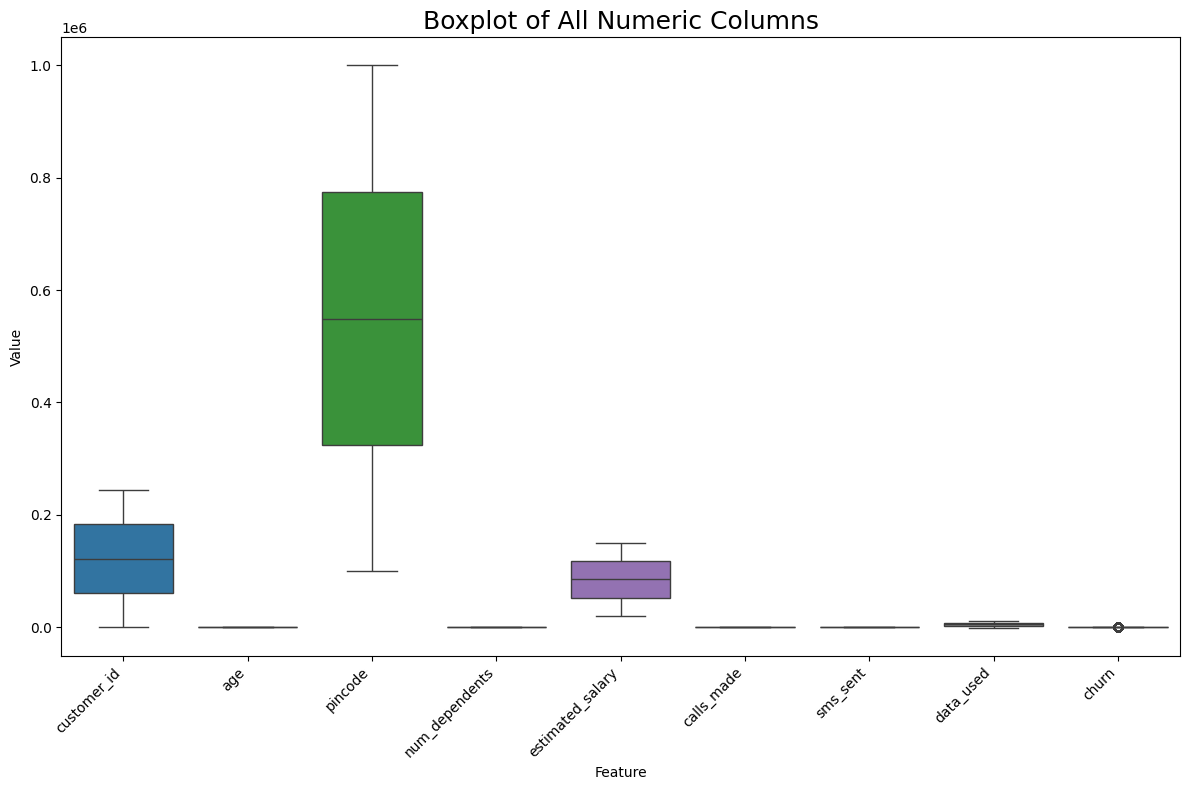

In [15]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=numeric_cols, orient='v')
plt.title("Boxplot of All Numeric Columns", fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Value')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()


* The box plot shows the distribution, median, and spread of numerical features. Some features show high variability and presence of outliers. Feature scaling may be required before applying machine learning algorithms.
* Not show the more outliers

**Churn Distribution**

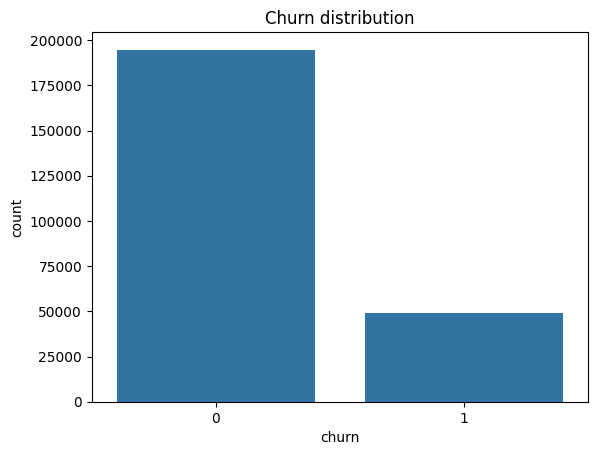

In [16]:
sns.countplot(x='churn', data=df)
plt.title('Churn distribution')
plt.show()

* The count plot shows the proportion of churn vs non-churn customers. If the dataset is imbalanced, techniques such as resampling or class weight adjustment may be required.

**Correlation heatmap Analysis**

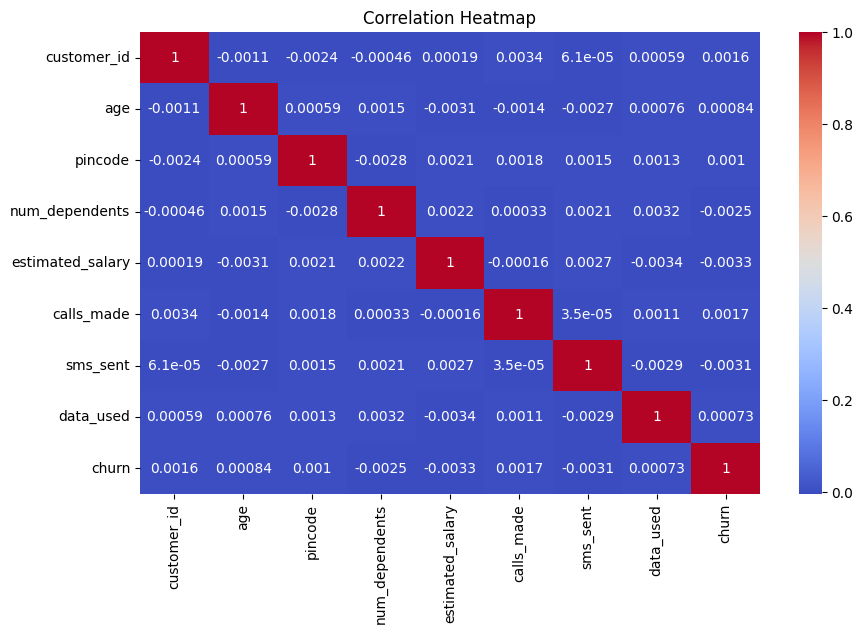

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

* The heatmap visualizes the correlation between numerical features. It helps identify strong relationships and detect multicollinearity. Some features show positive correlation, while most have weak correlation with churn, indicating that churn is influenced by multiple factors.

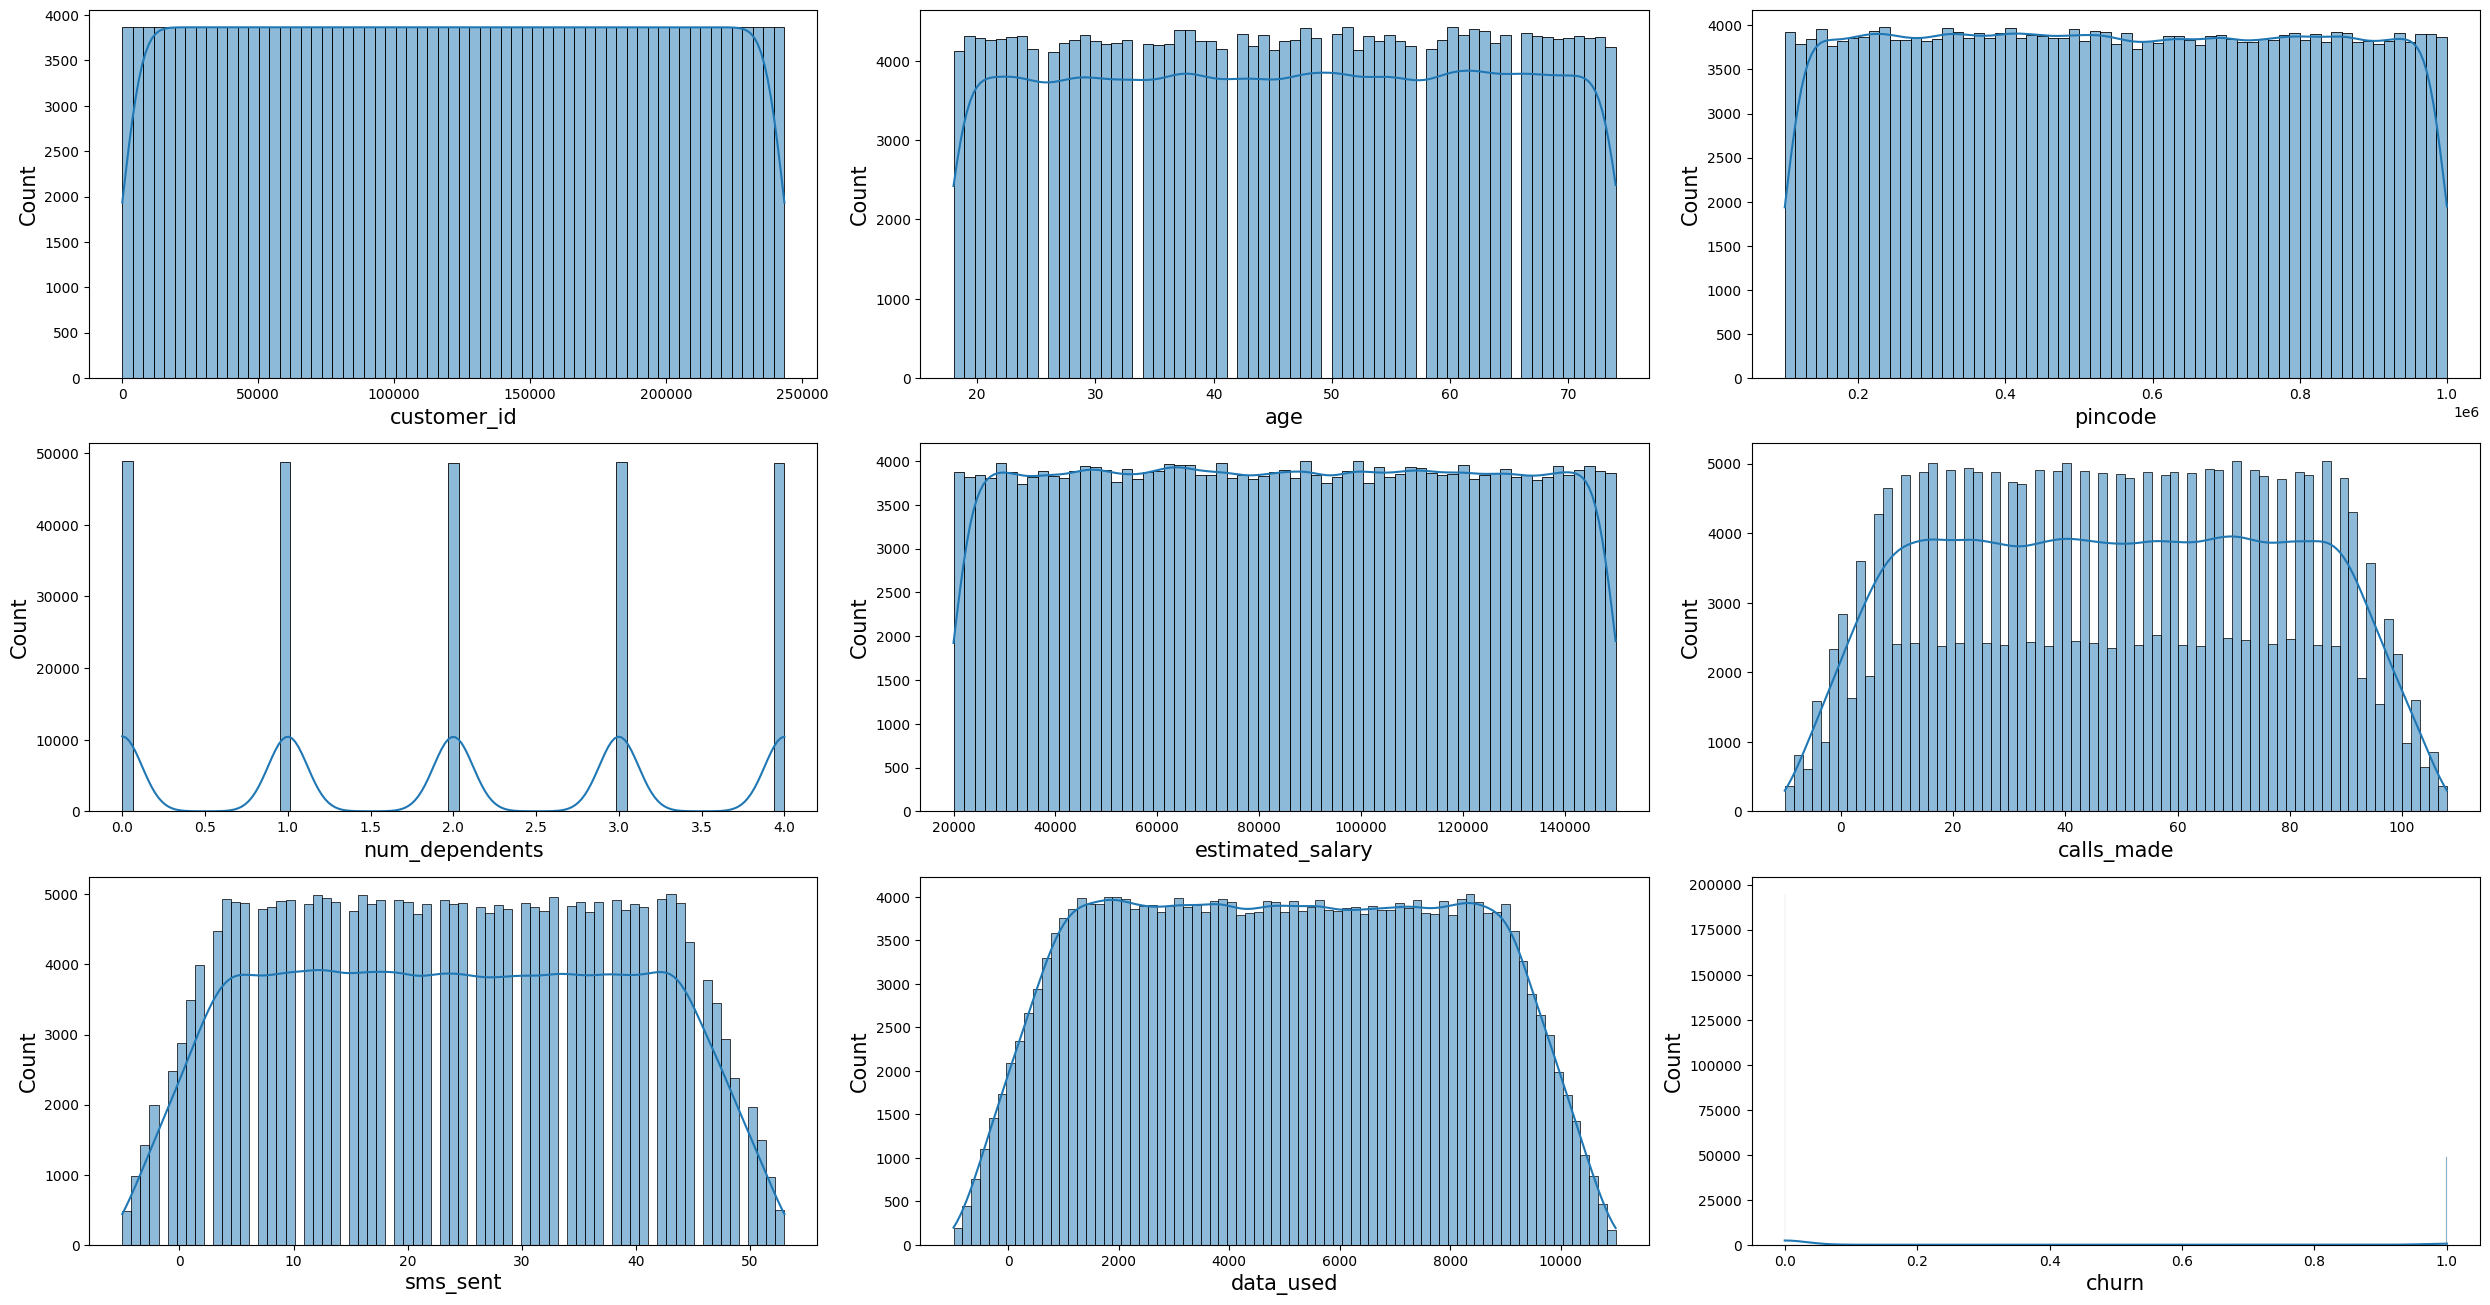

In [18]:
cat_des = ['telecom_partner','gender','state','city','date_of_registration']

plt.figure(figsize=(25,30))
num = 1

for column in df.drop(cat_des, axis=1):
    if num<=21:
        plt.subplot(7, 3, num)
        sns.histplot(df[column], kde=True)
        plt.xlabel(column,fontsize=15)
        plt.ylabel('Count',fontsize=15)
        plt.xticks(fontsize=10)
        plt.yticks(fontsize=10)
    num+=1

plt.tight_layout()
plt.show()

* The above histograms represent the distribution of numerical features in the dataset. The KDE curve helps in understanding the density and overall pattern of data distribution.

* From the visualizations, we can observe that:

* Features like age, estimated_salary, calls_made, sms_sent, and data_used show varying distributions.

* Some features appear normally distributed, while others show skewness (either right-skewed or left-skewed).

* Usage-related features such as calls_made, sms_sent, and data_used may have higher variability, indicating differences in customer behavior.

* If strong skewness is observed, data transformation techniques like log transformation may be applied to improve model performance.

**State-wise Customer Distribution Analysis:**

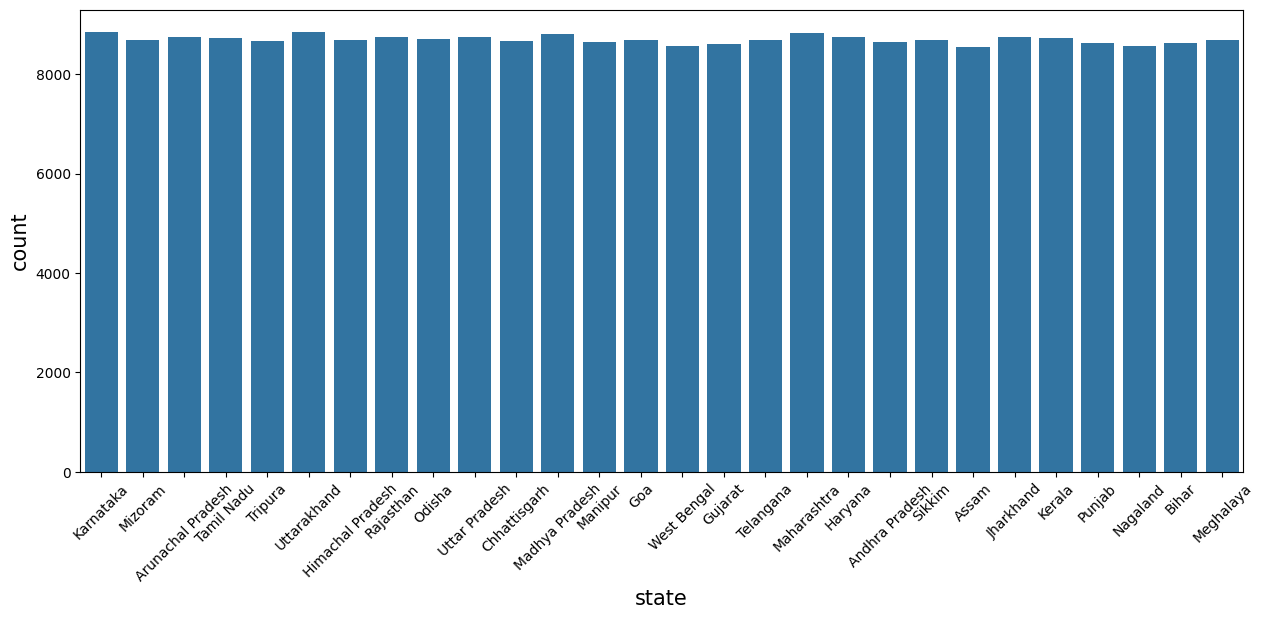

In [19]:
plt.figure(figsize=(15,6))
sns.countplot(x=df['state'])
plt.xlabel('state',fontsize=15)
plt.ylabel('count',fontsize=15)
plt.xticks(rotation=45)
plt.show()

* The count plot shows that Uttarakhand has the highest number of customers, followed closely by Karnataka and Maharashtra. This indicates strong market penetration and customer acquisition in these states.

* On the other hand, Assam, Nagaland, and West Bengal have comparatively lower customer counts. These states may represent potential areas for business expansion and targeted marketing strategies.

* Although the difference between states is not extremely large, the distribution suggests relatively balanced customer acquisition across regions, with slight dominance in certain states. Understanding state-wise distribution helps in identifying regional performance and planning localized retention strategies.

**Proper Percentage-wise Analysis (Format):**

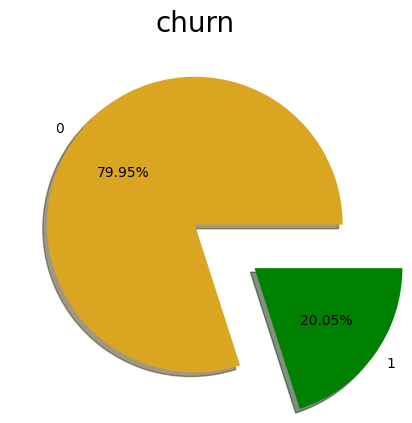

In [20]:
plt.pie(df["churn"].value_counts(),labels=[0,1] ,autopct='%1.2f%%' ,explode=(0,0.5) ,shadow=True,colors = ['goldenrod', 'green'])
plt.title('churn',fontsize = 20)
plt.show()


* (Assume example output: 0 → 79.95% , 1 → 20.05%)

* The pie chart shows that 79.95% of customers have not churned, while 20.05% of customers have churned.

* This indicates that the majority of customers are retained by the company, but a significant portion (around one-fourth) has discontinued the         service. The dataset shows a moderate class imbalance, where non-churn customers outnumber churn customers.

* This imbalance should be considered during model building, as it may affect prediction performance. Techniques such as class weighting or resampling can be applied to handle this issue effectively.

**Sampling Analysis**

In [21]:
df = df.sample(n=50000, random_state=45)
print("Random state shape is :", df.shape)

Random state shape is : (50000, 14)


* The dataset now contains 50,000 records and 14 features. Sampling was done to reduce computation time while keeping all features intact.

**Feature removel Analysis**

In [22]:
if 'customer_id' in df.columns:
    df = df.drop('customer_id', axis=1)

* The customer_id column was removed because it is just an identifier and has no impact on churn prediction. Only meaningful features should be used for model training.

**Feature and Target Saparation**

In [23]:
X = df.drop('churn', axis=1)
y = df['churn']

* in this step, the dataset is divided into independent variables (X) and the dependent variable (y).

* X (Features): Contains all input variables used to predict churn.

* y (Target Variable): Contains the output variable churn, which indicates whether a customer has left the service or not.

* Separating features and target variable is an essential step before training a machine learning model. It allows the model to learn patterns from input features and predict the target outcome effectively.

**Categorical Feature Encoding**

In [24]:
Label_Encoders = {}

for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    Label_Encoders[col] = le

* In this step, categorical (object-type) features were converted into numerical format using Label Encoding. Machine learning algorithms require numerical input, so categorical variables such as telecom_partner, gender, state, and city must be encoded before model training.

* A dictionary called label_encoders was used to store the encoder for each column. This ensures that the same encoding mapping can be reused later for transforming new or test data, maintaining consistency in predictions.

* Label Encoding assigns a unique numerical value to each category in a column. This transformation allows the model to process categorical data effectively.

In [25]:
X.head()

,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used
51373,2,1,48,23,3,926499,257,2,97390,68,2,8547
100343,3,1,66,11,0,300436,502,2,63130,74,20,3606
157418,0,1,57,10,4,617987,787,2,51645,101,20,5810
214744,3,0,44,7,0,131832,1074,0,110806,35,12,919
159643,1,0,38,11,3,102754,799,0,47402,68,31,1900


__Handling Class Imbalance:__

In [26]:
df_combined = pd.concat([X, y], axis=1)

majority = df_combined[df_combined.churn == 0]
minority = df_combined[df_combined.churn == 1]

minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

balanced_df = pd.concat([majority, minority_upsampled])

X_balanced = balanced_df.drop('churn', axis=1)
y_balanced = balanced_df['churn']

print("\nBalanced Class Distribution:")
print(y_balanced.value_counts())



Balanced Class Distribution:
churn
0    39963
1    39963
Name: count, dtype: int64


* After applying the upsampling technique, the dataset now contains:

* Churn = 0 (Non-Churn Customers): 39,963

* Churn = 1 (Churn Customers): 39,963

* This shows that both classes now have equal representation in the dataset. Previously, the dataset was imbalanced, with more non-churn customers than churn customers. By upsampling the minority class, the imbalance issue has been successfully resolved.

* Balancing the dataset ensures that the machine learning model does not become biased toward predicting the majority class. It improves the model’s ability to correctly identify churn customers, which is critical for business decision-making and customer retention strategies.

**Train-Test Split Analysis**

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced,
    y_balanced,
    test_size = 0.2,
    random_state = 42
)

* 80% of the data was used for training the model.

* 20% of the data was reserved for testing and evaluating model performance.

* random_state=42 ensures reproducibility of results.

* stratify=y_balanced ensures that both training and testing sets maintain equal class distribution (same proportion of churn and non-churn customers).

* Stratification is especially important in classification problems to prevent class imbalance in the test dataset. This step ensures that the model is trained on sufficient data and evaluated fairly on unseen data.

**Data Preprocessing using pipeline**

In [28]:
num_cols = [
    "age",
    "pincode",
    "num_dependents",
    "estimated_salary",
    "calls_made",
    "sms_sent",
    "data_used"
]

cat_cols = [
    "telecom_partner",
    "gender",
    "state",
    "city"
]


In [29]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

* In this step, a preprocessing pipeline was created to handle numerical features efficiently before model training.

* First, all numerical columns were identified from the training dataset. Then, a transformation pipeline was defined for numerical features, which includes:

* SimpleImputer (Median Strategy):
Missing values in numerical features are replaced with the median value. Median is chosen because it is robust to outliers.

* StandardScaler:
Numerical features are scaled to standardize their range. Scaling ensures that features with larger values do not dominate the model and improves algorithm performance.

* A ColumnTransformer was then created to apply these transformations only to numerical features, while other columns are passed through without modification (remainder='passthrough').

* This structured preprocessing approach ensures clean, consistent, and reproducible data preparation for machine learning models.

**Model Pipeline with RandomForest**

In [30]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    ))
])

model_pipeline.fit(X_train,y_train)

y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:,1]

**Model Prediction and probability Estimation**

In [31]:
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:,1]

* After training the model pipeline, predictions were made on the test dataset using the predict() function.

* y_pred contains the predicted class labels (0 or 1), indicating whether a customer is predicted to churn or not.

* y_proba contains the predicted probabilities of churn (class 1). It shows the likelihood of each customer churning, with values ranging between 0 and 1.

* The predict_proba() function is particularly useful for evaluating model performance using metrics such as ROC-AUC score. It also helps in business decision-making, as customers with higher churn probability can be targeted with retention strategies.

* Using both class predictions and probability scores ensures a comprehensive evaluation of the model's performance.

**Model Pipeline with Logistic Regreesion**

In [36]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',LogisticRegression())
])

lr_pipeline.fit(X_train,y_train)

lr_pred = lr_pipeline.predict(X_test)
lracc = accuracy_score(lr_pred,y_test)

**Model Pipeline with XGBoost**

In [32]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    ))
])

xgb_pipeline.fit(X_train,y_train)

xgb_pred = xgb_pipeline.predict(X_test)
acc = accuracy_score(xgb_pred,y_test)

**Model Evalution Analysis**

In [38]:
accuracy = accuracy_score(y_test,y_pred)
print('\RabdomForest Accuracy',accuracy)
print('\nLogistic Accuracy',lracc)
print('\nXGBoost Accuracy',acc)

print('\nClassification Report')
print(classification_report(y_test,y_pred))


\RabdomForest Accuracy 0.9767296384336295

Logistic Accuracy 0.498936569498311

XGBoost Accuracy 0.7157512823720755

Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      7975
           1       0.99      0.96      0.98      8011

    accuracy                           0.98     15986
   macro avg       0.98      0.98      0.98     15986
weighted avg       0.98      0.98      0.98     15986



* After generating predictions on the test dataset, the model performance was evaluated using Accuracy Score and Classification Report.

* Accuracy

* Accuracy measures the overall percentage of correctly predicted instances out of total test samples. It gives a general idea of model performance.

However, accuracy alone is not always sufficient, especially in classification problems.

**Classification Report**

The classification report provides detailed evaluation metrics:

Precision → Measures how many predicted churn cases were actually correct.

Recall → Measures how many actual churn cases were correctly identified.

F1-Score → Harmonic mean of Precision and Recall (balances both).

Support → Number of actual occurrences of each class in test data.

These metrics provide a deeper understanding of the model’s ability to correctly predict churn and non-churn customers.

🎯 Business Insight

High recall for churn class is particularly important in telecom churn prediction because missing a churn customer can lead to revenue loss. Therefore, the model should focus not only on accuracy but also on recall and F1-score.

🎯 Short Version (Viva Friendly)

Model performance was evaluated using accuracy and classification report. Precision, recall, and F1-score help in understanding how well the model predicts churn customers.

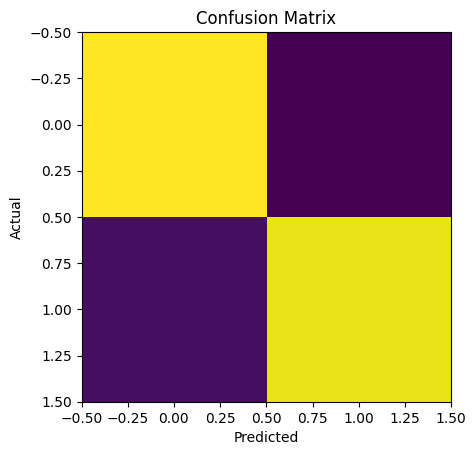

In [ ]:
cm = confusion_matrix(y_test,y_pred)

plt.figure()
plt.imshow(cm)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

True Positive high → churn detected correctly<br>
True Negative high → loyal customers detected correctly<br>
False Positive low → few loyal customers marked as churn<br>
False Negative low → few churn customers missed

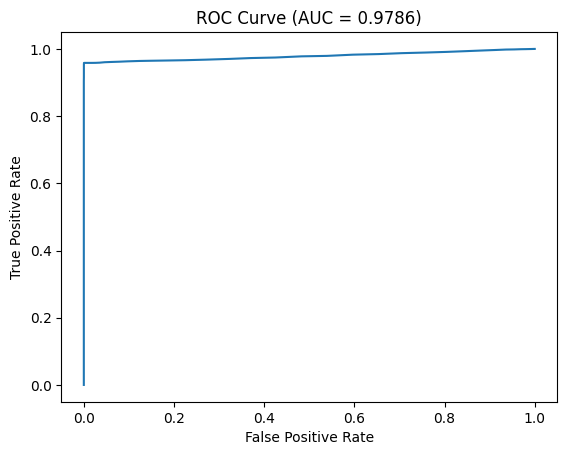

AUC Score: 0.9785986588190454


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AUC = %0.4f)" % roc_auc)
plt.show()

print("AUC Score:", roc_auc)


Model separates churn vs non-churn very well<br>
Very strong prediction power<br>
Very low overlap between classes<br>
ROC curve near top-left corner<br>
High TPR, low FPR

In [ ]:
import joblib

joblib.dump(model_pipeline, "churn_model.pkl")
print("Model saved successfully")


Model saved successfully


## Conclusion

The Telecom Churn Prediction model was built using Machine Learning algorithms including Logistic Regression, XGBoost, and Random Forest. After balancing the dataset and performing preprocessing, Random Forest achieved the best performance with 97% accuracy and ROC-AUC score of 0.978, indicating excellent classification ability.

The confusion matrix shows very low false predictions, and the ROC curve confirms strong model performance.

This model can be used by telecom companies to identify customers likely to churn and take preventive actions, improving customer retention and business revenue.

## Thank You !